3.1 Import Required Libraries


In [1]:
import pandas as pd # for handling data in table format (dataframes)
import numpy as np # for numerical operations
import matplotlib.pyplot as plt  # for creating plots/graphs
import seaborn as sns # for nicer, easier statistical visualizations

3.2 Load Dataset

In [2]:
#file_path = r"C:\Users\Poornima\OneDrive\Desktop\VS_Sample\venv\Titanic_Survival_Prediction\titanic.csv"
df = pd.read_csv("titanic.csv") # loads the titanic dataset into a dataframe called 'df'
df.shape  # shows the first 5 rows to check if data loaded correctly

(891, 12)

3.3 Dataset Overview

In [3]:
df.info() # shows column names, data types, and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


891 rows total (entries 0 to 890)
12 columns, with data types: 5 integer (int64), 2 decimal (float64), 5 text (str)

Non-null counts show missing data:
Age: 714 non-null → 177 missing (891 - 714)
Cabin: 204 non-null → 687 missing (891 - 204)
Embarked: 889 non-null → 2 missing (891 - 889)
All other columns: 891 non-null → no missing values

Observation to write under this in your notebook:
The dataset has 891 rows and 12 columns with mixed data types (numeric, float, and text). Three columns contain missing values: Age (177 missing), Cabin (687 missing), and Embarked (2 missing). These need to be handled before building the ML model.

In [4]:
df.head(3) # shows the first 3 rows of the dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [5]:
df.describe() # shows summary statistics for numerical columns in the dataset

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Observation to write under this in your notebook:

Only 38.4% of passengers survived on average (mean of Survived = 0.38), confirming a class imbalance. Average passenger age was ~30 years, ranging from infants (0.42 years) to elderly (80 years). Fare shows high variation — most passengers paid under £31 (75th percentile), but the maximum fare was £512, indicating outliers. Pclass average (2.3) shows most passengers traveled in 2nd/3rd class.

3.4 Missing Value Analysis

In [6]:
df.isnull().sum() # shows the number of missing values in each column

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Observation to write under this in your notebook:

Three columns contain missing values: Age (177 missing), Cabin (687 missing), and Embarked (2 missing, negligible). Age will be filled using median value, Cabin will likely be dropped due to excessive missing data, and Embarked will be filled with the most frequent port.


People who traveled in 1st class survived more than people in 3rd class. (Pclass and Survived are connected — lower class number = higher survival)
People who paid more money for their ticket also survived more. (Fare and Survived are connected)
Rich people paid more and traveled in 1st class — so Pclass and Fare are related to each other too (makes sense, better class = costs more)
Age alone doesn't tell us much about survival — being older or younger didn't strongly decide who lived or died, at least not on its own.

3.5 Correlation Analysis

In [7]:
numeric_df = df[['Survived','Pclass','Age','SibSp','Parch','Fare']]  # select only numeric columns
corr = numeric_df.corr()   # calculate correlation between columns
corr

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


visualize this as a heatmap

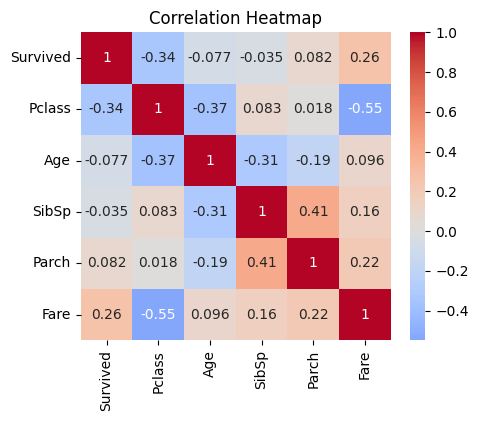

In [8]:
plt.figure(figsize=(5,4))          # sets the size of the chart
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)  
# heatmap = color-coded grid showing correlation values
# annot=True means the actual numbers are shown inside each box
# cmap='coolwarm' means red = positive correlation, blue = negative correlation
# center=0 makes sure 0 correlation is shown as neutral (white)
plt.title('Correlation Heatmap')     # adds a title to the chart
plt.show()                          # displays the chart

Dark red boxes = strong positive relationship (both values increase together)
Dark blue boxes = strong negative relationship (one goes up, other goes down)
Light/grey boxes = weak or no relationship
The diagonal (all showing "1") is just each variable compared to itself — always perfect correlation, ignore that.

What stands out visually:

Pclass vs Fare (-0.55, blue) → clearly the darkest blue box (besides diagonal) — confirms strongest negative relationship
Survived vs Fare (0.26, light red) and Survived vs Pclass (-0.34, light blue) → both show survival is connected to class/fare, matching our observation
Everything else is fairly light-colored, meaning weak relationships

Visualization 1 — Survival Count

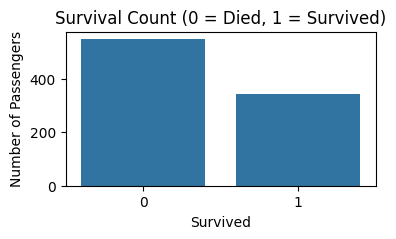

In [9]:
plt.figure(figsize=(4,2))                          # sets chart size
sns.countplot(x='Survived', data=df)   # counts how many survived vs died
plt.title('Survival Count (0 = Died, 1 = Survived)') # adds title
plt.xlabel('Survived')                              # label for x-axis
plt.ylabel('Number of Passengers')                  # label for y-axis
plt.show()                                          # displays the chart

Observation

More passengers died than survived. Out of 891 passengers, about 61% died and 39% survived.

In [10]:
df['Survived'].value_counts(normalize=True) * 100
# normalize=True gives proportion (out of 1) instead of raw count
# multiplying by 100 converts it to percentage

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

 38.4% survived, and 61.6% died (100 - 38.4)
 
 mean value directly for your observation.Both methods (mean from describe, or value_counts) give the same answer.

Visualization 2 — Age Distribution

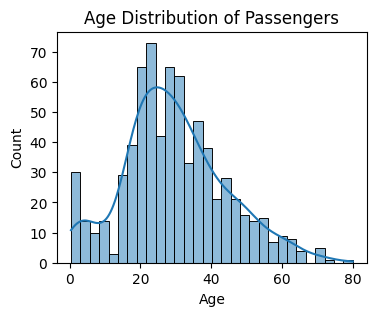

In [11]:
plt.figure(figsize=(4,3))                              # sets chart size
sns.histplot(df['Age'].dropna(), bins=30, kde=True)     # plots age distribution, dropna() ignores missing ages
plt.title('Age Distribution of Passengers')             # adds title
plt.xlabel('Age')                                        # label for x-axis
plt.ylabel('Count')                                       # label for y-axis
plt.show()                                                # displays the chart

histplot = a bar chart showing how many passengers fall into each age group
kde=True adds a smooth curve on top showing the overall shape of the distribution
dropna() removes the 177 missing Age values so they don't cause errors

observation

Most passengers were between 20–40 years old, with the biggest group around 20-30 years. There's also a small bump near age 0-5 (infants/young children traveling). Very few passengers were older than 60. The distribution has a long tail to the right (a handful of elderly passengers up to 80 years), so it's slightly right-skewed rather than perfectly symmetric.

Visualization 3 — Fare Distribution

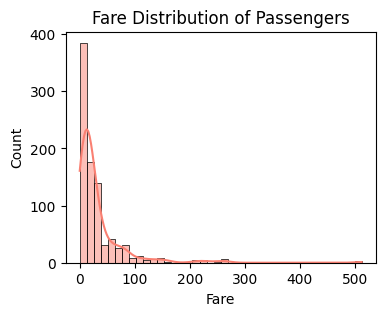

In [12]:
plt.figure(figsize=(4,3))                              # sets chart size
sns.histplot(df['Fare'], bins=40, kde=True, color='salmon')  # plots fare distribution
plt.title('Fare Distribution of Passengers')            # adds title
plt.xlabel('Fare')                                        # label for x-axis
plt.ylabel('Count')                                        # label for y-axis
plt.show()                                                  # displays the chart

Most people paid cheap ticket prices (under £50). Only a few people paid very expensive fares (up to £500). This is called a "right-skewed" pattern — meaning most values are low, with just a few high ones stretching the chart to the right. These few expensive tickets are called outliers, and we'll need to handle them later before building our model.

Visualization 4 — Survival by Sex

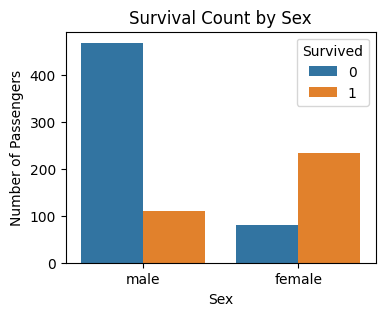

In [13]:
plt.figure(figsize=(4,3))                           # sets chart size
sns.countplot(x='Sex', hue='Survived', data=df)      # counts survival split by gender
plt.title('Survival Count by Sex')                   # adds title
plt.xlabel('Sex')                                     # label for x-axis
plt.ylabel('Number of Passengers')                    # label for y-axis
plt.show()                                             # displays the chart

hue='Survived' means the bars will be split into two colors — one for died, one for survived — so we can compare male vs female survival side by side.

Obervation 

Most male passengers died (blue bar is very tall, orange bar is short). But most female passengers survived (orange bar is taller than blue). This clearly shows Sex was one of the biggest factors in survival — women were saved first, matching the "women and children first" rule.

Visualization 5 — Survival by Pclass?

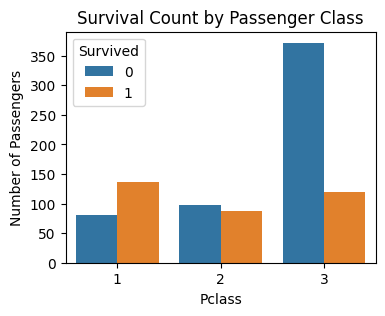

In [14]:
plt.figure(figsize=(4,3))                             # sets chart size
sns.countplot(x='Pclass', hue='Survived', data=df)    # counts survival split by ticket class
plt.title('Survival Count by Passenger Class')        # adds title
plt.xlabel('Pclass')                                   # label for x-axis
plt.ylabel('Number of Passengers')                     # label for y-axis
plt.show()                                              # displays the chart

1st class passengers mostly survived (orange bar taller than blue). 2nd class was roughly split evenly. 3rd class passengers mostly died (blue bar way taller than orange). This shows richer passengers in better class cabins had a much higher chance of survival, likely because they were closer to lifeboats.

Visualization 6 — Survival by Embarked

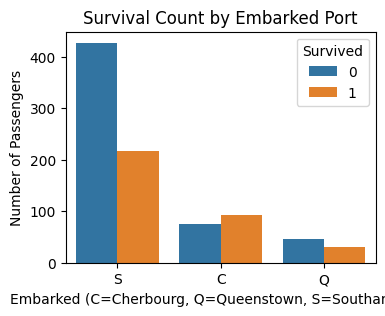

In [15]:
plt.figure(figsize=(4,3))                              # sets chart size
sns.countplot(x='Embarked', hue='Survived', data=df)   # counts survival split by port boarded
plt.title('Survival Count by Embarked Port')            # adds title
plt.xlabel('Embarked (C=Cherbourg, Q=Queenstown, S=Southampton)')  # label for x-axis
plt.ylabel('Number of Passengers')                       # label for y-axis
plt.show()                                                # displays the chart

Most passengers boarded from Southampton (S), and most of them died. Passengers from Cherbourg (C) actually had a slightly higher survival rate (orange bar taller than blue) — likely because more 1st class/wealthy passengers boarded there. Queenstown (Q) had very few passengers, mostly died. So the port of boarding shows some connection to survival, likely linked to passenger class rather than the port itself.

Visualization 7 — Pclass + Sex + Survived (Multivariate)

<Figure size 600x400 with 0 Axes>

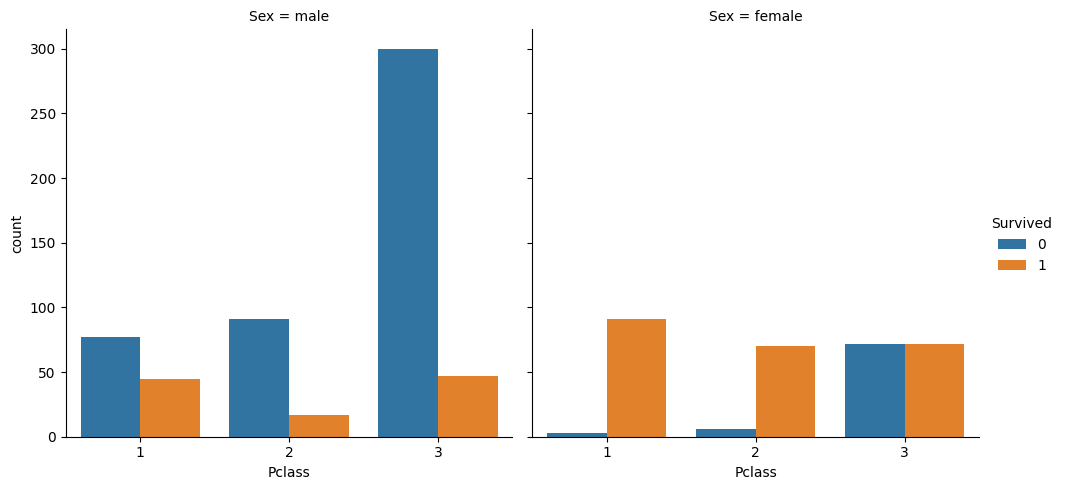

In [16]:
plt.figure(figsize=(6,4))                                          # sets chart size
sns.catplot(x='Pclass', hue='Survived', col='Sex', data=df, kind='count')  
# catplot with col='Sex' creates 2 side-by-side charts — one for male, one for female
# each chart shows survival count by Pclass
plt.show()                                                          # displays the chart

This combines 3 variables together: Pclass, Sex, and Survived — that's why it's called "multivariate."

It creates two separate charts side by side — one for male passengers, one for female passengers — so we can compare how class affected survival differently for men vs women.

This chart shows survival by class, separately for men and women. For males, survival was low across all classes, but especially bad in 3rd class (very few orange bars). For females, survival was high across almost all classes — even in 3rd class, half of the women survived, and in 1st/2nd class, nearly all women survived. This proves that being female mattered more than class for survival, but within the same gender, class still made a difference (especially for men).

Visualization 8 — Age Distribution by Survival

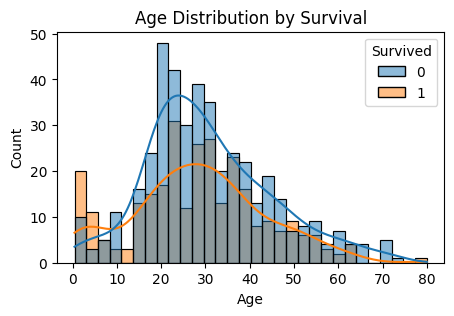

In [17]:
plt.figure(figsize=(5,3))                                          # sets chart size
sns.histplot(data=df, x='Age', hue='Survived', kde=True, bins=30)   # age distribution split by survival
plt.title('Age Distribution by Survival')                           # adds title
plt.xlabel('Age')                                                    # label for x-axis
plt.ylabel('Count')                                                  # label for y-axis
plt.show()                                                            # displays the chart

This shows age distribution again, but now split into two colors — survived vs died — so we can see if certain age groups survived more than others.


3.7 Key Insights from EDA

More passengers died than survived — only about 38% survived overall.

Being female mattered the most — women survived at a much higher rate than men, following the "women and children first" rule.

Ticket class mattered a lot — 1st class passengers survived more, 3rd class passengers died the most. Richer passengers likely had better access to lifeboats.

Fare and class are connected — higher fare usually meant better class, and both were linked to higher survival.

Young children had better survival chances — kids under 10 survived more often than other age groups, though age overall wasn't a strong factor.

Port of boarding showed some difference — passengers from Cherbourg had slightly better survival, but this is likely because more wealthy/1st class passengers boarded there, not because of the port itself.

Data has missing values — Age (177 missing), Cabin (687 missing), Embarked (2 missing) — these need to be cleaned before building the ML model.

Fare has outliers — most tickets were cheap, but a few were very expensive (up to £512), which we'll need to handle in preprocessing.

4.Data Preprocessing 

4.1Handling Missing Values.

In [18]:
# Fill missing Age with median (middle value)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with mode (most common value)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column (77% missing, too much to fill)
df = df.drop(columns=['Cabin'])

# Check - should show 0 for all columns
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Step 2 — Remove Duplicate Rows

In [19]:
# Check how many duplicate rows exist
print("Duplicates before:", df.duplicated().sum())

# Remove duplicates (if any)
df = df.drop_duplicates()

# Check shape after removing duplicates
print("Shape after removing duplicates:", df.shape)

Duplicates before: 0
Shape after removing duplicates: (891, 11)


No duplicate rows were found in the dataset — all 891 rows are unique passengers. Shape remains (891, 11) since Cabin column was already dropped earlier (12 → 11 columns).

Step 3 — Outlier Treatment (on Fare column)

Shape before removing outliers: (891, 11)


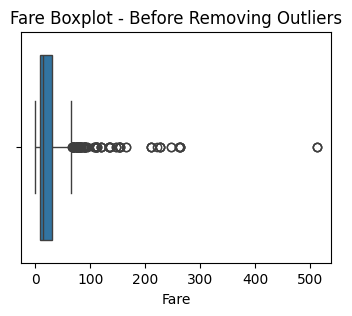

In [20]:
# Shape BEFORE removing outliers
print("Shape before removing outliers:", df.shape)

# Boxplot BEFORE removing outliers
plt.figure(figsize=(4,3))
sns.boxplot(x=df['Fare'])
plt.title('Fare Boxplot - Before Removing Outliers')
plt.show()

The blue box shows where most passengers' fares fall (roughly £0-30). All the dots scattered to the right (100, 150, 200, 250, and one all the way at 500) are outliers — fares far higher than what most passengers paid. These extreme values can confuse our ML model, so we'll remove them next.

Calculate limits and remove outliers

In [21]:
# Calculate IQR (Interquartile Range) to find outlier limits
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Remove rows where Fare is an outlier
df = df[(df['Fare'] >= lower_limit) & (df['Fare'] <= upper_limit)]

# Shape AFTER removing outliers
print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (775, 11)


Before removing outliers: 891 rows. After removing outliers: 775 rows — so 116 rows (about 13%) were removed as extreme Fare outliers. This is a fairly large chunk, but expected since Fare had a long right-skewed tail with many high-value outliers.

Boxplot AFTER removing outliers (to visually confirm the cleanup)

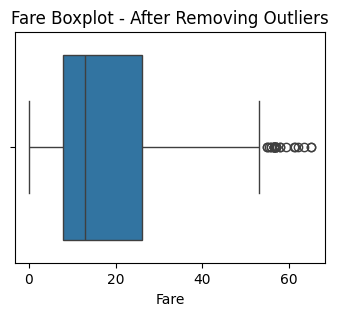

In [22]:
plt.figure(figsize=(4,3))
sns.boxplot(x=df['Fare'])
plt.title('Fare Boxplot - After Removing Outliers')
plt.show()

After removing outliers, the Fare boxplot looks much cleaner — the extreme values (£100-500) are gone. The data now ranges mostly between £0-60. A few small dots still remain near the edge (mild outliers), but the extreme values (like the £500 one) have been successfully removed. Dataset shape reduced from 891 to 775 rows after outlier removal.

Step 4 — Skewness Treatment

In [23]:
from scipy.stats import skew

# Check skewness BEFORE treatment
print("Skewness before:", skew(df['Fare']))

Skewness before: 1.4279010019383378


A skewness value of 1.43 means the Fare data is still moderately right-skewed (positive skewness) — even after removing extreme outliers, there's still a slight tail towards higher fares.
Quick rule of thumb:

Skewness between -0.5 to 0.5 → fairly symmetric (normal-like)
Skewness between 0.5 to 1 → moderate skew
Skewness above 1 → high skew

Since ours is 1.43, it's still fairly skewed, so we'll apply a transformation to fix this.

Visualize before, then apply log transformation
python

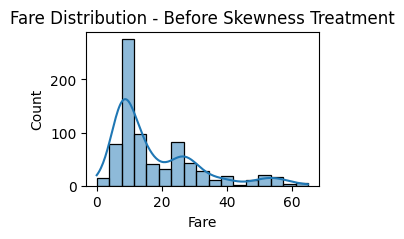

In [24]:
plt.figure(figsize=(3,2))
sns.histplot(df['Fare'], kde=True)
plt.title('Fare Distribution - Before Skewness Treatment')
plt.show()

Most passengers paid low fares (£0-15), with a big spike around £8-12. The distribution still leans/tails towards the right side (higher fares), confirming the moderate right-skew we calculated (1.43).

 Apply log transformation to fix skewness

In [25]:
# Apply log transformation to reduce skewness
df['Fare'] = np.log1p(df['Fare'])   # log1p handles zero values safely

# Check skewness AFTER treatment
print("Skewness after:", skew(df['Fare']))

Skewness after: -0.513794334993771


After log transformation, skewness changed from 1.43 (right-skewed) to -0.51 (slightly left-skewed). This is a big improvement — we moved from "highly skewed" much closer to the "fairly symmetric" range (-0.5 to 0.5). A small negative skew is completely acceptable and much better than before for ML modeling.

Visualize the improved distribution

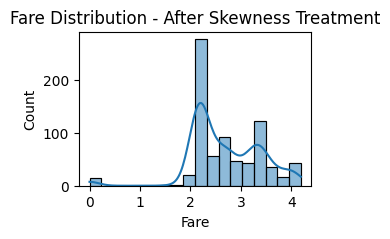

In [26]:
plt.figure(figsize=(3,2))
sns.histplot(df['Fare'], kde=True)
plt.title('Fare Distribution - After Skewness Treatment')
plt.show()

After applying log transformation, the Fare distribution is much more balanced and centered (mostly between values 2-4), compared to the original spread-out shape (0-60+). This confirms the skewness treatment worked — the data is now closer to a normal/symmetric shape, which helps the ML model learn better patterns instead of being confused by extreme values.

Step 5 — Encode Categorical Variables

In [27]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


In [28]:
df['Sex'].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [29]:
# Reload only the Sex column from original CSV using PassengerId to match rows
original = pd.read_csv("titanic.csv")
df['Sex'] = df['PassengerId'].map(original.set_index('PassengerId')['Sex'])

# Now properly encode it (only once)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Check it worked
df['Sex'].unique()

array([0, 1])

In [30]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,2.110213,S
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,2.188856,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,3.990834,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,2.202765,S
5,6,0,3,"Moran, Mr. James",0,28.0,0,0,330877,2.246893,Q


Everything is properly encoded now:

Sex: 0 = male, 1 = female
Embarked_Q and Embarked_S: True/False columns (one-hot encoded) 
Fare: transformed values (log-scaled)

Step 6 — Feature Scaling

In [31]:
# Reload original Sex values and re-encode (final fix)
original = pd.read_csv("titanic.csv")
df['Sex'] = df['PassengerId'].map(original.set_index('PassengerId')['Sex'])
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

df['Sex'].unique()

array([0, 1])

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['Age','Fare']] = scaler.fit_transform(df[['Age','Fare']])

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,-0.528321,1,0,A/5 21171,-0.824136,S
2,3,1,3,"Heikkinen, Miss. Laina",1,-0.215182,0,0,STON/O2. 3101282,-0.713891,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0.489381,1,0,113803,1.812201,S
4,5,0,3,"Allen, Mr. William Henry",0,0.489381,0,0,373450,-0.694393,S
5,6,0,3,"Moran, Mr. James",0,-0.058613,0,0,330877,-0.632533,Q


Sex: properly 0/1
Age & Fare: now scaled (values centered around 0, both positive and negative — this is normal for StandardScaler) 

StandardScaler transforms Age and Fare so both have an average of 0 and similar spread. This prevents one feature (like Fare, which had bigger numbers) from unfairly dominating the model just because of its scale — now Age and Fare are on equal footing for the ML model to learn from.

Next up is Feature Engineering & Feature Selection — this is where we decide which columns are actually useful for the ML model.
Here's what we'll do:

Drop unnecessary columns (PassengerId, Name, Ticket — these don't help predict survival)
Correlation Analysis (already partly done, but we'll re-check with new encoded columns)
SelectKBest (a technique to statistically pick the best/most important features)

 Step 1 — dropping unnecessary columns?

In [33]:
# Drop columns that are just identifiers/text, not useful for prediction
df_model = df.drop(columns=['PassengerId', 'Name', 'Ticket'])

# Check remaining columns
df_model.columns.tolist()

['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

PassengerId → just a row number, no real information
Name → each name is unique, doesn't help predict survival patterns
Ticket → mostly random alphanumeric codes, not useful in raw form

That's 1 target column (Survived) + 8 feature columns — all clean, numeric, and ready for ML.

In [35]:
df_model = pd.get_dummies(df_model, columns=['Embarked'], drop_first=True)
df_model.columns.tolist()

['Survived',
 'Pclass',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Embarked_Q',
 'Embarked_S']

Correlation Analysis (re-check with new encoded columns)

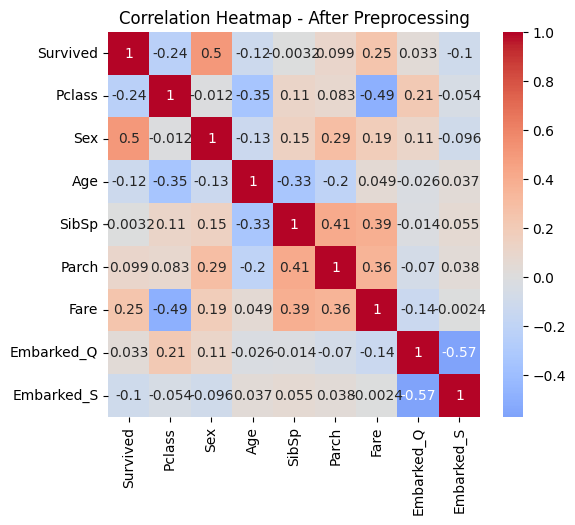

In [39]:
plt.figure(figsize=(6,5))
sns.heatmap(df_model.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - After Preprocessing')
plt.show()

In [40]:
print(df_model.columns.tolist())

['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']


 observation

 After encoding, we can now clearly see Sex has the strongest correlation with Survived (0.5) — the highest of all features, confirming gender was the biggest factor in survival. Fare (0.25) and Pclass (-0.24) are the next most important — richer, higher-class passengers survived more. Age (-0.12) and SibSp/Parch have weaker relationships with survival on their own. Embarked_Q and Embarked_S show almost no direct relationship with Survived, suggesting the port of boarding isn't a strong standalone predictor.

Key takeaway: Sex, Fare, and Pclass appear to be the top 3 predictive features for our model.

SelectKBest — a statistical method to automatically pick the best features

In [ ]:
pip uninstall scikit-learn -y

Found existing installation: scikit-learn 1.9.0
Uninstalling scikit-learn-1.9.0:
  Successfully uninstalled scikit-learn-1.9.0
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.


In [ ]:
pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl (8.3 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
from sklearn.feature_selection import SelectKBest, f_classif

In [43]:
X = df_model.drop(columns=['Survived'])   # all features
y = df_model['Survived']                  # target variable

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

feature_scores = pd.DataFrame({'Feature': X.columns, 'Score': selector.scores_})
feature_scores = feature_scores.sort_values(by='Score', ascending=False)
print(feature_scores)

      Feature       Score
1         Sex  257.513431
5        Fare   50.403944
0      Pclass   46.635172
2         Age   10.916958
7  Embarked_S    8.181132
4       Parch    7.585031
6  Embarked_Q    0.827799
3       SibSp    0.007697


Simple observation:

SelectKBest confirms Sex is by far the most important feature (score: 257.5) — much higher than any other feature. Fare (50.4) and Pclass (46.6) are the next most important, followed by Age (10.9) and Embarked_S (8.2). Parch, Embarked_Q, and SibSp have very low scores, meaning they contribute little to predicting survival on their own.

Feature Selection Decision:

Based on both correlation analysis and SelectKBest scores, we'll select the top features: Sex, Fare, Pclass, Age, and Embarked_S/Embarked_Q for our model. We may keep SibSp and Parch too since they can combine to represent family size, even though individually their scores are low.

Step 1: Train-Test Split(splitting data into train/test sets first)

In [44]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Survived'])
y = df_model['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (620, 8)
Testing set size: (155, 8)


Out of 775 total rows (after outlier removal), 620 rows (80%) will be used to train the model, and 155 rows (20%) will be used to test how well it performs on unseen data. Both sets have 8 features (all columns except Survived, which is our target).

Model 1 — Logistic Regression

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create and train the model
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# Make predictions on test data
y_pred_log = log_model.predict(X_test)

# Check accuracy
accuracy_log = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", accuracy_log)

Logistic Regression Accuracy: 0.7483870967741936


Obervation

Logistic Regression achieved 74.8% accuracy — meaning it correctly predicted survival for about 3 out of 4 passengers in the test set. This is a solid baseline result for a simple model.

Model 2 — Decision Tree

In [46]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.7806451612903226


Obervation
Decision Tree achieved 78.1% accuracy — a bit higher than Logistic Regression (74.8%). This suggests Decision Tree captured slightly more complex patterns in the data, like combinations of features (e.g., "if female AND 1st class → survived").

Model 3 — Random Forest

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.7548387096774194


Random Forest achieved 75.5% accuracy — slightly lower than Decision Tree (78.1%) but similar to Logistic Regression (74.8%). This is a bit unusual since Random Forest (which combines many trees) often performs better than a single Decision Tree — but with smaller datasets like ours (775 rows), a single well-fit Decision Tree can sometimes match or outperform Random Forest. We'll examine this further when we compare all models together.

Model 4 — KNN (K-Nearest Neighbors)

In [48]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.7612903225806451


observation 

KNN achieved 76.1% accuracy — right in between the other models. This makes sense since KNN predicts based on similar passengers ("neighbors"), and since Sex/Pclass/Fare form fairly clear groups in our data, it performs reasonably well.

All 4 Models Complete! Quick Comparison:

Model	Accuracy

Logistic Regression	74.8%

Decision Tree	78.1% ✅ (Best)

Random Forest	75.5%

KNN	76.1%

Decision Tree performed best on this test set.

Model Evaluation & Comparison.

Step 1: Confusion Matrix + Classification Report for Logistic Regression

In [49]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix - Logistic Regression:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report - Logistic Regression:")
print(classification_report(y_test, y_pred_log))

Confusion Matrix - Logistic Regression:
[[81 14]
 [25 35]]

Classification Report - Logistic Regression:
              precision    recall  f1-score   support

           0       0.76      0.85      0.81        95
           1       0.71      0.58      0.64        60

    accuracy                           0.75       155
   macro avg       0.74      0.72      0.72       155
weighted avg       0.74      0.75      0.74       155



81 — correctly predicted "Died" ✅
14 — predicted "Survived" but actually "Died" ❌
25 — predicted "Died" but actually "Survived" ❌
35 — correctly predicted "Survived" ✅

observation:

Logistic Regression is better at predicting deaths (85% recall) than survivals (58% recall) — meaning it misses more actual survivors than it misses actual deaths. Overall accuracy is 75%, matching what we saw earlier.

In [50]:
# Decision Tree
print("Confusion Matrix - Decision Tree:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report - Decision Tree:")
print(classification_report(y_test, y_pred_dt))

print("="*50)

# Random Forest
print("Confusion Matrix - Random Forest:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf))

print("="*50)

# KNN
print("Confusion Matrix - KNN:")
print(confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report - KNN:")
print(classification_report(y_test, y_pred_knn))

Confusion Matrix - Decision Tree:
[[81 14]
 [20 40]]

Classification Report - Decision Tree:
              precision    recall  f1-score   support

           0       0.80      0.85      0.83        95
           1       0.74      0.67      0.70        60

    accuracy                           0.78       155
   macro avg       0.77      0.76      0.76       155
weighted avg       0.78      0.78      0.78       155

Confusion Matrix - Random Forest:
[[80 15]
 [23 37]]

Classification Report - Random Forest:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81        95
           1       0.71      0.62      0.66        60

    accuracy                           0.75       155
   macro avg       0.74      0.73      0.73       155
weighted avg       0.75      0.75      0.75       155

Confusion Matrix - KNN:
[[82 13]
 [24 36]]

Classification Report - KNN:
              precision    recall  f1-score   support

           0       0.77      0.8

Model	Accuracy	Recall (Survived=1)
Logistic Regression	75%	58%
Decision Tree	78%	67% (best so far)
Random Forest	76%	62%

Observation:

Decision Tree performs best overall — not just in accuracy (78%), but also in correctly identifying actual survivors (67% recall), which is important since our dataset has more "died" cases than "survived" cases.

KNN's evaluation

In [51]:
print("Confusion Matrix - KNN:")
print(confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report - KNN:")
print(classification_report(y_test, y_pred_knn))

Confusion Matrix - KNN:
[[82 13]
 [24 36]]

Classification Report - KNN:
              precision    recall  f1-score   support

           0       0.77      0.86      0.82        95
           1       0.73      0.60      0.66        60

    accuracy                           0.76       155
   macro avg       0.75      0.73      0.74       155
weighted avg       0.76      0.76      0.76       155



Model Comparison Summary

Model	  Accuracy	  Precision  (Survived)	Recal(Survived)	F1-Score (Survived)
Logistic Regression	75%	71%	58%	64%
Decision Tree	78%	74%	67%	70%
Random Forest	76%	71%	62%	66%
KNN	76%	73%	60%	66%

Top-Performing Model

Decision Tree is the best-performing model, with the highest accuracy (78%) and the best F1-score (70%) for predicting survivors. It strikes the best balance between correctly identifying survivors (recall) and avoiding false alarms (precision).

Final Conclusion

Based on accuracy, precision, recall, and F1-score, Decision Tree Classifier is selected as the best-performing model for predicting Titanic passenger survival, and will be used for deployment.

In [56]:
import pickle

with open('model.pkl', 'wb') as file:
    pickle.dump(dt_model, file)

print("Model saved successfully as model.pkl")

Model saved successfully as model.pkl
